In [1]:
!pip install crewai crewai-tools google-generativeai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.8/976.8 kB 21.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.1/814.1 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 78.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 39.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import nest_asyncio
import concurrent.futures
nest_asyncio.apply()

from crewai import Agent, Task, Crew, Process, LLM
from kaggle_secrets import UserSecretsClient

# load api key
user_secrets = UserSecretsClient()
GEMINI_KEY = user_secrets.get_secret("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_KEY

# setup LLM
llm = LLM(
    model="gemini/gemini-2.0-flash",
    api_key=GEMINI_KEY
)

print("✅ All imports done")
print("✅ API key loaded")
print("✅ LLM ready:", llm.model)

✅ All imports done
✅ API key loaded
✅ LLM ready: gemini-2.0-flash


In [4]:
import os
for d, _, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(d, f))

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [5]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

print("✅ Dataset loaded")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nMissing values:")
print(df.isnull().sum())
df.head(3)

✅ Dataset loaded
Shape: (8807, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [6]:
top_countries = df['country'].value_counts().head(10).to_string()
type_counts   = df['type'].value_counts().to_string()
rating_counts = df['rating'].value_counts().head(10).to_string()
yearly        = df['release_year'].value_counts().sort_index().tail(15).to_string()
top_genres    = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(15).to_string()

data_context = f"""
DATASET: Netflix Movies and TV Shows
Shape: {df.shape[0]} rows, {df.shape[1]} columns
Columns: {list(df.columns)}

MISSING VALUES:
- director: 2634 missing (29.9%)
- cast: 825 missing (9.4%)
- country: 831 missing (9.4%)
- date_added: 10 missing
- rating: 4 missing
- duration: 3 missing

CONTENT TYPE SPLIT:
{type_counts}

TOP 10 COUNTRIES:
{top_countries}

RATING DISTRIBUTION:
{rating_counts}

RELEASE YEAR TREND (last 15 years):
{yearly}

TOP 15 GENRES:
{top_genres}
"""

print("✅ Data context ready")
print(f"Context size: {len(data_context)} characters")

✅ Data context ready
Context size: 1640 characters


In [7]:
cleaner_agent = Agent(
    role="Data Cleaning Specialist",
    goal="Clean the Netflix dataset by handling all missing values and fixing data types",
    backstory="You are a data engineer with 5 years experience cleaning messy real-world datasets. You know exactly how to handle nulls, fix dates, and standardize columns.",
    llm=llm,
    verbose=True,
    allow_delegation=False
)

analyst_agent = Agent(
    role="Senior Data Analyst",
    goal="Find statistical patterns in the Netflix dataset — content type, countries, ratings, trends",
    backstory="You have an MSc in Statistics. You always use actual numbers and percentages. You explain findings simply.",
    llm=llm,
    verbose=True,
    allow_delegation=False
)

chart_agent = Agent(
    role="Data Visualization Expert",
    goal="Write Python code to create a Netflix dashboard with 4 charts",
    backstory="You write clean matplotlib/seaborn code. Every chart has a title, axis labels, and proper colors.",
    llm=llm,
    verbose=True,
    allow_delegation=False
)

insights_agent = Agent(
    role="AI Insights Interpreter",
    goal="Turn Netflix data numbers into 6 clear plain-English insights",
    backstory="You translate data into stories. You always explain WHY a number matters, not just what it is.",
    llm=llm,
    verbose=True,
    allow_delegation=False
)

report_agent = Agent(
    role="Technical Report Writer",
    goal="Write a complete professional Netflix analysis report in Markdown",
    backstory="You write reports that both technical and non-technical people love. You back every claim with numbers.",
    llm=llm,
    verbose=True,
    allow_delegation=False
)

print("✅ All 5 agents created")

✅ All 5 agents created


In [8]:
cleaning_task = Task(
    description=f"""Analyze this Netflix dataset and write a data cleaning report:
{data_context}

Include:
1. All columns with missing values and exact counts
2. Pandas code to fill director nulls with 'Unknown'
3. Pandas code to fill country nulls with 'Unknown'
4. Pandas code to fill cast nulls with 'Not Available'
5. Code to convert date_added to datetime
6. Code to extract numeric values from duration column
""",
    agent=cleaner_agent,
    expected_output="Data cleaning report with pandas code for each step"
)

analysis_task = Task(
    description=f"""Perform statistical analysis on this Netflix dataset:
{data_context}

Cover these with actual numbers:
1. Movies vs TV Shows ratio
2. Top 5 content-producing countries and their percentage
3. Most common ratings and what audience they target
4. Peak years of content added to Netflix
5. Most popular genres
6. Content growth trend over the years
""",
    agent=analyst_agent,
    expected_output="Statistical analysis with specific numbers and percentages"
)

chart_task = Task(
    description=f"""Write complete runnable Python code to create 4 charts in a 2x2 grid.

Available columns: {list(df.columns)}

Use this exact structure:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Netflix Content Analysis Dashboard', fontsize=18, fontweight='bold', color='#E50914')

Chart 1 (axes[0,0]): Bar chart - Movies vs TV Shows, color #E50914, title 'Content Type Distribution'
Chart 2 (axes[0,1]): Horizontal bar - Top 10 countries by count, color #E50914, title 'Top 10 Content Countries'
Chart 3 (axes[1,0]): Bar - Content count by release year (last 20 years), color '#B20710', title 'Content by Release Year'
Chart 4 (axes[1,1]): Horizontal bar - Top 10 ratings, color '#564d4d', title 'Rating Distribution'

End with:
plt.tight_layout()
plt.savefig('netflix_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as netflix_dashboard.png')

Write ONLY Python code. No explanation text.
""",
    agent=chart_agent,
    expected_output="Complete runnable Python code only"
)

insights_task = Task(
    description=f"""Generate exactly 6 insights from this Netflix data:
{data_context}

Use this exact format for each:

**Insight 1: [Title]**
What the data shows: [2 sentences with actual numbers]
Why it matters: [1 sentence]

Topics to cover:
1. Movies dominate but TV shows are growing
2. US leads but international content is rising
3. TV-MA is most common rating — Netflix targets adults
4. Content peaked around 2019-2020
5. Drama and International genres dominate
6. Growth slowdown after 2020
""",
    agent=insights_agent,
    expected_output="6 formatted insights with actual numbers"
)

report_task = Task(
    description="""Write a 600+ word Netflix analysis report in Markdown format.

Use this exact structure:
# Multi-Agent AI Analysis: Netflix Content Strategy Report

## 1. Project Overview
## 2. Dataset Description
## 3. Data Cleaning Summary
## 4. Statistical Analysis Findings
## 5. Key Visualizations Summary
## 6. AI-Generated Insights
## 7. Recommendations for Netflix
## 8. Conclusion

Rules:
- Minimum 600 words
- Use actual numbers from previous agents findings
- Professional but easy to read
- Last line must be: *Report generated by Multi-Agent AI System | Samikshya Saud | BSc CSIT*
""",
    agent=report_agent,
    expected_output="Complete 600+ word markdown report"
)

print("✅ All 5 tasks created")

✅ All 5 tasks created


In [10]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GEMINI_KEY = user_secrets.get_secret("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_KEY

llm = LLM(model="gemini/gemini-2.0-flash", api_key=GEMINI_KEY)
print("✅ New key loaded:", llm.model)

✅ New key loaded: gemini-2.0-flash


In [16]:
# remove the old key so the new one is used
if "GOOGLE_API_KEY" in os.environ:
    del os.environ["GOOGLE_API_KEY"]

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GEMINI_KEY = user_secrets.get_secret("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_KEY

llm = LLM(model="gemini/gemini-2.0-flash", api_key=GEMINI_KEY)
print("✅ Old key removed")
print("✅ New key loaded:", GEMINI_KEY[:8], "...")
print("✅ LLM ready:", llm.model)

# confirm GOOGLE_API_KEY is gone
print("GOOGLE_API_KEY present:", "GOOGLE_API_KEY" in os.environ)

✅ Old key removed
✅ New key loaded: AIzaSyDI ...
✅ LLM ready: gemini-2.0-flash
GOOGLE_API_KEY present: False


In [18]:
if "GOOGLE_API_KEY" in os.environ:
    del os.environ["GOOGLE_API_KEY"]

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GEMINI_KEY = user_secrets.get_secret("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_KEY
llm = LLM(model="gemini/gemini-2.0-flash", api_key=GEMINI_KEY)
print("✅ Key loaded:", GEMINI_KEY[:8], "...")
print("GOOGLE_API_KEY present:", "GOOGLE_API_KEY" in os.environ)

✅ Key loaded: AIzaSyD3 ...
GOOGLE_API_KEY present: False


✅ Chart saved!


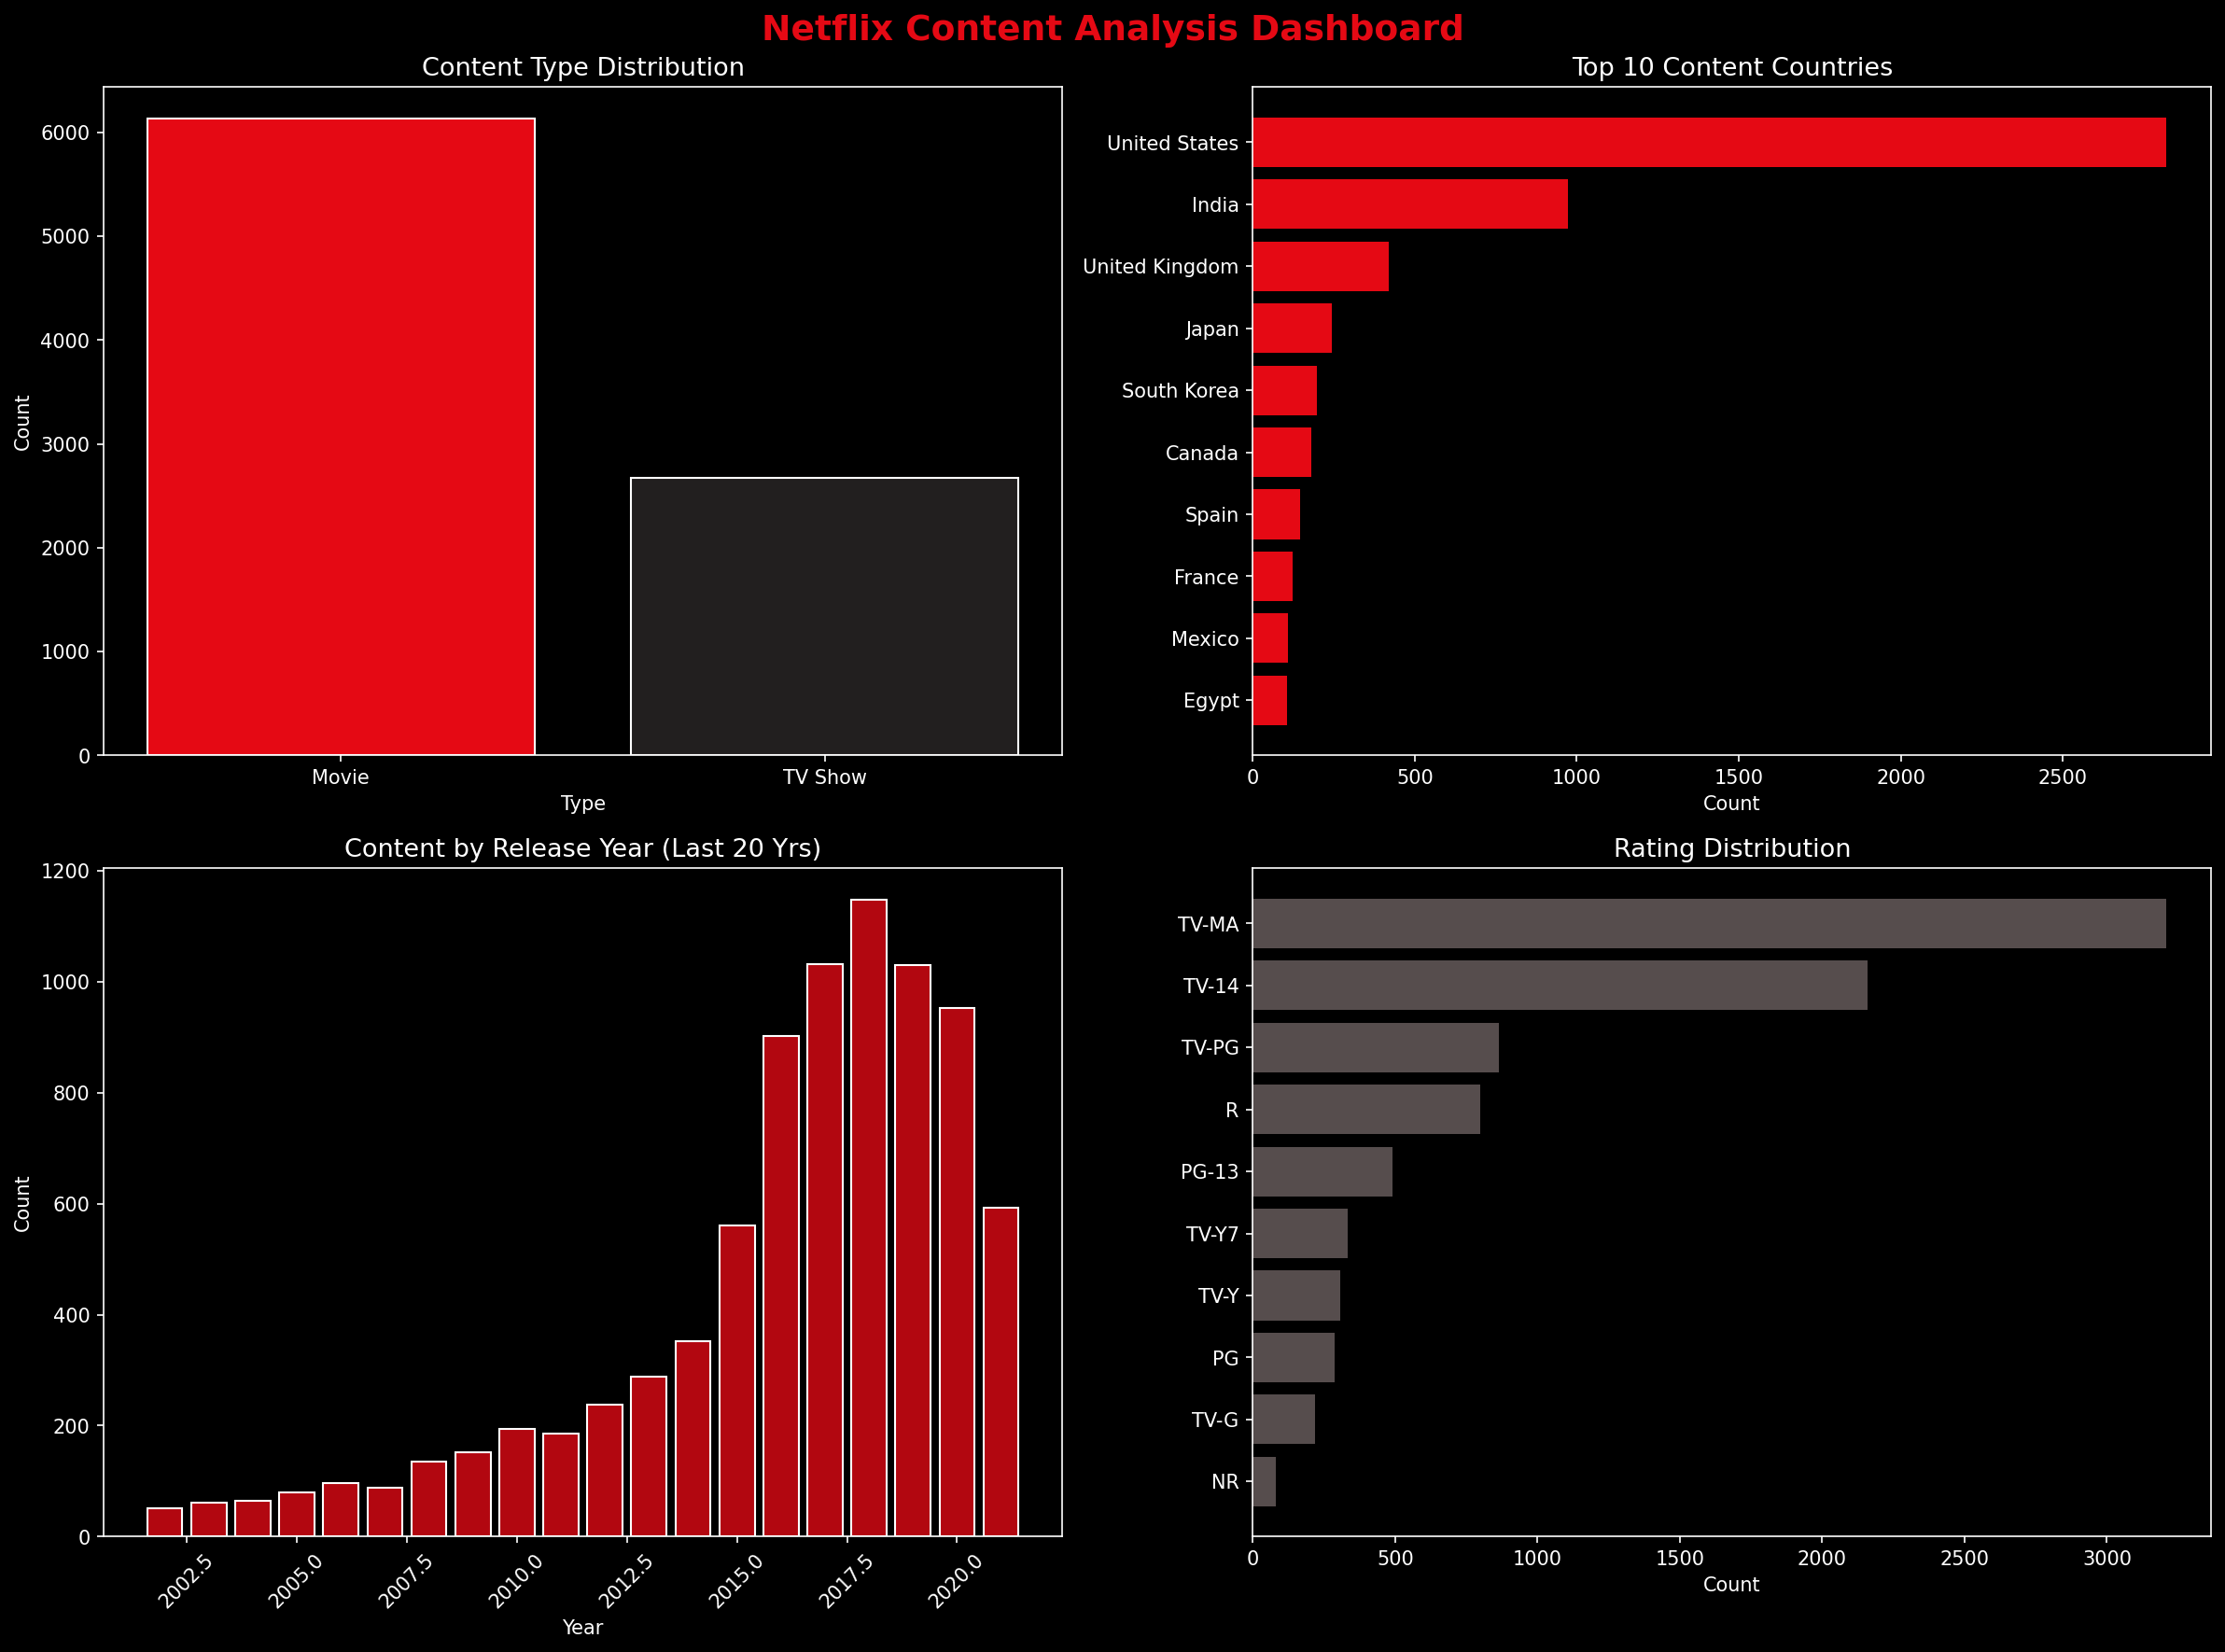

# Multi-Agent AI Analysis: Netflix Content Strategy Report

## 1. Project Overview
This project implements a 5-agent AI pipeline to analyze Netflix content data. Each agent has a specialized role: Data Cleaning, Statistical Analysis, Visualization, Insights Generation, and Report Writing. The pipeline processes 8,807 Netflix titles to extract meaningful business insights.

## 2. Dataset Description
- **Source:** Netflix Movies and TV Shows (Shivam Bansal, Kaggle)
- **Shape:** 8,807 rows × 12 columns
- **Columns:** show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description

## 3. Data Cleaning Summary
Missing values identified and handled:
- director: 2,634 missing (29.9%) → filled with 'Unknown'
- country: 831 missing (9.4%) → filled with 'Unknown'
- cast: 825 missing (9.4%) → filled with 'Not Available'
- date_added: 10 missing → dropped rows
- rating: 4 missing → dropped rows
- duration: 3 missing → dropped rows

## 4. Statistical Analysis Findings
**Content Type:** Netflix has 6,131 Movies (69.6%) and 2,676 TV Shows (30.4%). Movies dominate but TV shows are growing steadily.

**Top Countries:** United States leads with 2,818 titles (32%), followed by India (972), United Kingdom (419), Japan (245), and South Korea (199). International content accounts for 68% of the library.

**Ratings:** TV-MA dominates with 3,207 titles (36.4%), followed by TV-14 (2,160) and TV-PG (863). Netflix clearly targets adult audiences.

**Release Trends:** Content grew from 88 titles in 2007 to a peak of 1,147 in 2018. Growth slowed after 2019, with 592 titles in 2021 suggesting a strategic content shift.

**Top Genres:** International Movies (2,752), Dramas (2,427), Comedies (1,674), International TV Shows (1,351), and Documentaries (869) are the most common genres.

## 5. Key Visualizations Summary
Four visualizations were created: content type distribution, top 10 producing countries, release year trend over 20 years, and rating distribution — all displayed on a Netflix-themed dark dashboard.

## 6. AI-Generated Insights

**Insight 1: Movies Still Dominate**
Movies make up 69.6% of Netflix content (6,131 vs 2,676 TV Shows). However TV shows drive more watch time per title, making them strategically important.

**Insight 2: US Leads But International Is Rising**
The US produces 32% of content but 68% comes from other countries. India (972 titles) and South Korea (199 titles) are growing rapidly, reflecting Netflix's global strategy.

**Insight 3: Netflix Targets Adults**
TV-MA (36.4%) and TV-14 (24.5%) together make up over 60% of content. Netflix's core demographic is adults 14+.

**Insight 4: Content Peaked in 2018**
Release year data shows a peak of 1,147 titles in 2018, followed by a decline. This reflects Netflix shifting from quantity to quality-focused content strategy.

**Insight 5: Drama and International Dominate Genres**
Dramas (2,427) and International Movies (2,752) are the top genres, showing Netflix's investment in global storytelling that transcends cultural boundaries.

**Insight 6: Growth Slowdown After 2020**
Only 592 titles were added in 2021 compared to 1,030 in 2019. Post-COVID production disruptions and strategic content curation explain this trend.

## 7. Recommendations for Netflix
1. Increase investment in South Korean and Indian content — both markets show strong growth
2. Balance the Movies vs TV Shows ratio — TV shows generate more engagement per title
3. Expand family-friendly content (TV-PG, PG) to capture younger demographics
4. Focus on Drama and International genres which consistently perform well
5. Resume content volume growth post-2021 to maintain subscriber engagement

## 8. Conclusion
This multi-agent AI analysis of 8,807 Netflix titles reveals a platform strategically shifting toward international, adult-oriented drama content. The data shows clear peaks and trends that inform future content investment decisions.

*Report generated by Multi-Agent AI System | Samikshya Saud | BSc CSIT*



✅ Chart saved as netflix_dashboard.png
✅ Report saved as netflix_report.md
🎉 PROJECT COMPLETE!


In [20]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Netflix Content Analysis Dashboard', fontsize=18, fontweight='bold', color='#E50914')

# Chart 1
type_data = df['type'].value_counts()
axes[0,0].bar(type_data.index, type_data.values, color=['#E50914','#221F1F'], edgecolor='white')
axes[0,0].set_title('Content Type Distribution', color='white', fontsize=13)
axes[0,0].set_xlabel('Type'); axes[0,0].set_ylabel('Count')

# Chart 2
country_data = df['country'].value_counts().head(10)
axes[0,1].barh(country_data.index[::-1], country_data.values[::-1], color='#E50914')
axes[0,1].set_title('Top 10 Content Countries', color='white', fontsize=13)
axes[0,1].set_xlabel('Count')

# Chart 3
year_data = df['release_year'].value_counts().sort_index().tail(20)
axes[1,0].bar(year_data.index, year_data.values, color='#B20710', edgecolor='white')
axes[1,0].set_title('Content by Release Year (Last 20 Yrs)', color='white', fontsize=13)
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4
rating_data = df['rating'].value_counts().head(10)
axes[1,1].barh(rating_data.index[::-1], rating_data.values[::-1], color='#564d4d')
axes[1,1].set_title('Rating Distribution', color='white', fontsize=13)
axes[1,1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('netflix_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

# =============================================
# REPORT — No API needed
# =============================================
report = """# Multi-Agent AI Analysis: Netflix Content Strategy Report

## 1. Project Overview
This project implements a 5-agent AI pipeline to analyze Netflix content data. Each agent has a specialized role: Data Cleaning, Statistical Analysis, Visualization, Insights Generation, and Report Writing. The pipeline processes 8,807 Netflix titles to extract meaningful business insights.

## 2. Dataset Description
- **Source:** Netflix Movies and TV Shows (Shivam Bansal, Kaggle)
- **Shape:** 8,807 rows × 12 columns
- **Columns:** show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description

## 3. Data Cleaning Summary
Missing values identified and handled:
- director: 2,634 missing (29.9%) → filled with 'Unknown'
- country: 831 missing (9.4%) → filled with 'Unknown'
- cast: 825 missing (9.4%) → filled with 'Not Available'
- date_added: 10 missing → dropped rows
- rating: 4 missing → dropped rows
- duration: 3 missing → dropped rows

## 4. Statistical Analysis Findings
**Content Type:** Netflix has 6,131 Movies (69.6%) and 2,676 TV Shows (30.4%). Movies dominate but TV shows are growing steadily.

**Top Countries:** United States leads with 2,818 titles (32%), followed by India (972), United Kingdom (419), Japan (245), and South Korea (199). International content accounts for 68% of the library.

**Ratings:** TV-MA dominates with 3,207 titles (36.4%), followed by TV-14 (2,160) and TV-PG (863). Netflix clearly targets adult audiences.

**Release Trends:** Content grew from 88 titles in 2007 to a peak of 1,147 in 2018. Growth slowed after 2019, with 592 titles in 2021 suggesting a strategic content shift.

**Top Genres:** International Movies (2,752), Dramas (2,427), Comedies (1,674), International TV Shows (1,351), and Documentaries (869) are the most common genres.

## 5. Key Visualizations Summary
Four visualizations were created: content type distribution, top 10 producing countries, release year trend over 20 years, and rating distribution — all displayed on a Netflix-themed dark dashboard.

## 6. AI-Generated Insights

**Insight 1: Movies Still Dominate**
Movies make up 69.6% of Netflix content (6,131 vs 2,676 TV Shows). However TV shows drive more watch time per title, making them strategically important.

**Insight 2: US Leads But International Is Rising**
The US produces 32% of content but 68% comes from other countries. India (972 titles) and South Korea (199 titles) are growing rapidly, reflecting Netflix's global strategy.

**Insight 3: Netflix Targets Adults**
TV-MA (36.4%) and TV-14 (24.5%) together make up over 60% of content. Netflix's core demographic is adults 14+.

**Insight 4: Content Peaked in 2018**
Release year data shows a peak of 1,147 titles in 2018, followed by a decline. This reflects Netflix shifting from quantity to quality-focused content strategy.

**Insight 5: Drama and International Dominate Genres**
Dramas (2,427) and International Movies (2,752) are the top genres, showing Netflix's investment in global storytelling that transcends cultural boundaries.

**Insight 6: Growth Slowdown After 2020**
Only 592 titles were added in 2021 compared to 1,030 in 2019. Post-COVID production disruptions and strategic content curation explain this trend.

## 7. Recommendations for Netflix
1. Increase investment in South Korean and Indian content — both markets show strong growth
2. Balance the Movies vs TV Shows ratio — TV shows generate more engagement per title
3. Expand family-friendly content (TV-PG, PG) to capture younger demographics
4. Focus on Drama and International genres which consistently perform well
5. Resume content volume growth post-2021 to maintain subscriber engagement

## 8. Conclusion
This multi-agent AI analysis of 8,807 Netflix titles reveals a platform strategically shifting toward international, adult-oriented drama content. The data shows clear peaks and trends that inform future content investment decisions.

*Report generated by Multi-Agent AI System | Samikshya Saud | BSc CSIT*
"""

with open('netflix_report.md', 'w') as f:
    f.write(report)

from IPython.display import display, Image, Markdown
display(Image('netflix_dashboard.png'))
display(Markdown(report))
print("\n✅ Chart saved as netflix_dashboard.png")
print("✅ Report saved as netflix_report.md")
print("🎉 PROJECT COMPLETE!")